# 07 - Theme sentiment (the JPM-style sector chart)

Rolls the post-level sentiment scores (cached by notebook 06 - run it
first and this reuses the cache for free) up **per THEME per day**: the
JPM-style multi-line sector chart plus a theme momentum map. Themes are
the TRADEABLE buckets from `src/themes.py`, each anchored to an ETF in
`THEME_ETFS`.

Same FAQ as notebook 06 applies: gaps = the masking floor (auto-scaled
when sampling); the bullish-looking LEVELS are a real retail bias, so the
map's y-axis uses the CHANGE vs each theme's own window average; the map
is a snapshot of the LAST 5 DAYS, with the rest of the window as
baseline. Theme lines aggregate hundreds of posts/day, so they are much
more stable than single tickers (why JPM publishes the sector version).

Keep `MAX_SCORE_POSTS` identical to notebook 06 so both share one cache.

In [1]:
import os, sys
ROOT = os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) == 'notebooks' else os.getcwd()
sys.path.insert(0, ROOT)
print('project root:', ROOT)

project root: c:\Users\alexd\Desktop\GIC\RetailFlow1


In [2]:
# ============ PARAMETERS - edit these ============
SLICE_PATH      = os.path.join(ROOT, 'data', 'processed', 'posts_slice.parquet')
SENTIMENT_CACHE = os.path.join(ROOT, 'data', 'processed', 'posts_slice_sentiment.parquet')
SENTIMENT_OUT   = os.path.join(ROOT, 'data', 'processed', 'daily_theme_sentiment.parquet')
THEMES          = []       # e.g. ['gold_metals', 'semiconductors']; [] = TOP_N by posts
TOP_N           = 6
MIN_POSTS       = 20       # masking floor at FULL scoring (auto-scales when sampling)
ROLL            = 7        # rolling window (days), like JPM's weekly rolling
MAX_SCORE_POSTS = 500_000  # KEEP IDENTICAL to notebook 06 to share its cache
N_JOBS          = -1       # CPU cores for scoring; -1 = all of them
# ==================================================

In [3]:
# Load cached post-level scores (or score with the same parallel logic).
import pandas as pd
import importlib
import src.themes, src.sentiment
importlib.reload(src.themes)
importlib.reload(src.sentiment)
from src.sentiment import add_sentiment_fast, build_daily_theme_sentiment
from src.themes import THEME_ETFS

if not os.path.exists(SLICE_PATH):
    raise FileNotFoundError('posts_slice.parquet not found - run notebook 01 first.')
posts = pd.read_parquet(SLICE_PATH, columns=['date', 'title', 'selftext', 'score'])
WINDOW = f"{posts['date'].min()} to {posts['date'].max()}"
print(f'slice: {len(posts):,} posts | window: {WINDOW}')

expected_n = len(posts) if MAX_SCORE_POSTS is None else min(MAX_SCORE_POSTS, len(posts))
SAMPLE_FRAC = expected_n / len(posts)
MIN_POSTS_EFF = MIN_POSTS if SAMPLE_FRAC >= 1 else max(3, round(MIN_POSTS * SAMPLE_FRAC))
if SAMPLE_FRAC < 1:
    print(f'sampling {SAMPLE_FRAC:.0%} -> masking floor scaled {MIN_POSTS} -> {MIN_POSTS_EFF}')

scored = None
if os.path.exists(SENTIMENT_CACHE):
    scored = pd.read_parquet(SENTIMENT_CACHE)
    if len(scored) != expected_n:
        print('cache does not match this slice/budget - rescoring...')
        scored = None
    else:
        print('loaded cached sentiment scores (thanks, notebook 06)')
if scored is None:
    to_score = posts if expected_n == len(posts) else posts.sample(expected_n, random_state=0)
    if expected_n < len(posts):
        print(f'SAMPLING: scoring {expected_n:,} of {len(posts):,} posts ({SAMPLE_FRAC:.0%}, seed=0)')
    import time; t0 = time.time()
    scored = add_sentiment_fast(to_score, n_jobs=N_JOBS)
    print(f'scored {len(scored):,} posts in {time.time() - t0:.0f}s')
    scored.to_parquet(SENTIMENT_CACHE, index=False)

theme_sent = build_daily_theme_sentiment(scored)
theme_sent['date'] = pd.to_datetime(theme_sent['date'])
theme_sent.to_parquet(SENTIMENT_OUT, index=False)
print('rows:', len(theme_sent), '-> saved', SENTIMENT_OUT)

if THEMES:
    chosen = THEMES
else:
    chosen = list(theme_sent.groupby('theme')['n_posts'].sum()
                  .sort_values(ascending=False).head(TOP_N).index)
print('charting:', chosen)

slice: 2,833,008 posts | window: 2021-01-01 to 2021-12-31
sampling 18% -> masking floor scaled 20 -> 4
loaded cached sentiment scores (thanks, notebook 06)
rows: 6312 -> saved c:\Users\alexd\Desktop\GIC\RetailFlow1\data\processed\daily_theme_sentiment.parquet
charting: ['crypto', 'meme_stocks', 'short_squeeze', 'financials', 'ai_megacap', 'consumer_retail']


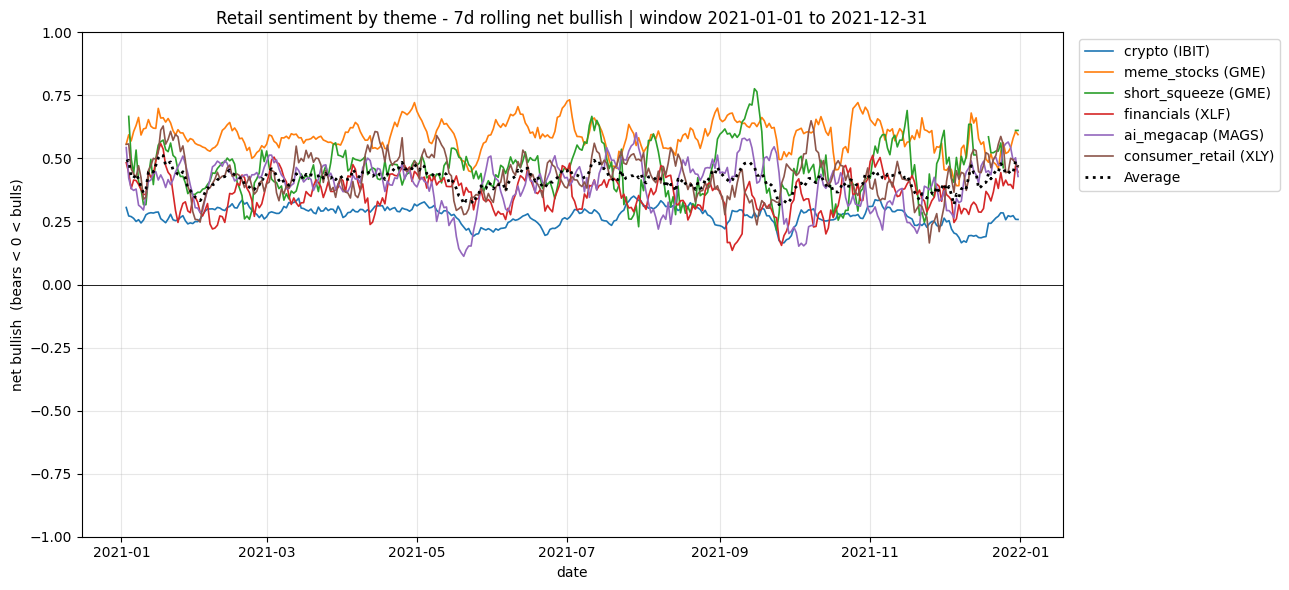

In [4]:
# THE JPM-STYLE CHART - rolling net_bullish per theme + dotted average.
import matplotlib.pyplot as plt

all_days = pd.date_range(theme_sent['date'].min(), theme_sent['date'].max(), freq='D')

def rolled_line(theme):
    one = (theme_sent[theme_sent['theme'] == theme]
           .set_index('date').reindex(all_days))
    net = one['net_bullish'].where(one['n_posts'].fillna(0) >= MIN_POSTS_EFF)
    return net.rolling(ROLL, min_periods=max(2, ROLL // 2)).mean()

plt.figure(figsize=(13, 6))
lines = {}
for theme in chosen:
    lines[theme] = rolled_line(theme)
    plt.plot(lines[theme].index, lines[theme], linewidth=1.2,
             label=f"{theme} ({THEME_ETFS.get(theme, '?')})")

avg = pd.concat(lines.values(), axis=1).mean(axis=1)
plt.plot(avg.index, avg, 'k:', linewidth=2, label='Average')

plt.axhline(0, color='black', linewidth=0.6)
plt.ylim(-1, 1)
plt.ylabel('net bullish  (bears < 0 < bulls)')
plt.xlabel('date')
plt.title(f'Retail sentiment by theme - {ROLL}d rolling net bullish | window {WINDOW}')
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

## Theme momentum map - LAST 5 DAYS vs the window baseline

One dot per theme, labelled with its ETF anchor. **x = mention momentum**
(last 5 days' post volume vs the theme's own window baseline, z-score);
**y = sentiment CHANGE** (last 5 days minus the theme's own window
average - cancels the retail bullish-level bias); **colour** = absolute
5-day lean; **bubble** = total posts. Top-right = crowd piling in AND
mood improving - first place to check against the anchor ETF's chart.

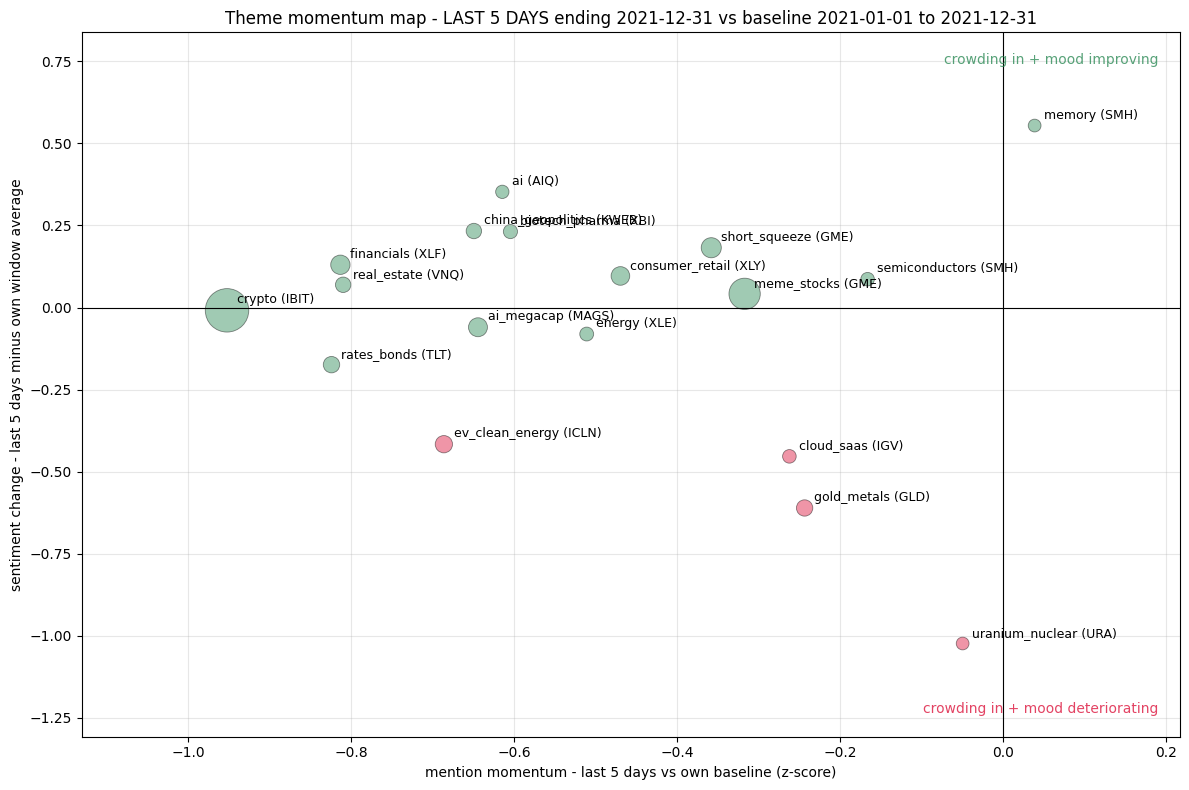

            theme  etf  posts_total  lookback_z  sent_5d  sent_delta
           crypto IBIT        75363       -0.95     0.26       -0.01
      meme_stocks  GME        35904       -0.32     0.63        0.04
    short_squeeze  GME        10863       -0.36     0.63        0.18
       financials  XLF         9565       -0.81     0.49        0.13
       ai_megacap MAGS         8909       -0.64     0.34       -0.06
  consumer_retail  XLY         8397       -0.47     0.52        0.10
  ev_clean_energy ICLN         6317       -0.69    -0.03       -0.42
      rates_bonds  TLT         5019       -0.82     0.20       -0.17
      gold_metals  GLD         4927       -0.24    -0.22       -0.61
      real_estate  VNQ         3702       -0.81     0.46        0.07
china_geopolitics KWEB         3659       -0.65     0.46        0.23
   biotech_pharma  XBI         2016       -0.60     0.67        0.23
           energy  XLE         1672       -0.51     0.38       -0.08
       cloud_saas  IGV         136

In [5]:
# Build per-theme stats and draw the map (axes auto-fit, nothing clips).
rows = []
for theme, grp in theme_sent.groupby('theme'):
    grp = grp.set_index('date').reindex(all_days)
    n = grp['n_posts'].fillna(0)
    if n.sum() < MIN_POSTS_EFF * 5:
        continue
    base_std = n.std()
    lookback_z = (n.iloc[-5:].mean() - n.mean()) / base_std if base_std > 0 else 0.0
    sent_5d = grp['net_bullish'].iloc[-5:].mean()
    sent_base = grp['net_bullish'].mean()
    if pd.isna(sent_5d) or pd.isna(sent_base):
        continue
    rows.append({'theme': theme, 'etf': THEME_ETFS.get(theme, ''),
                 'posts_total': int(n.sum()), 'lookback_z': float(lookback_z),
                 'sent_5d': float(sent_5d), 'sent_delta': float(sent_5d - sent_base)})

m = pd.DataFrame(rows)
SNAPSHOT = all_days[-1].date()

fig, ax = plt.subplots(figsize=(12, 8))
sizes = 80 + 900 * (m['posts_total'] / m['posts_total'].max())
colors = ['seagreen' if s >= 0 else 'crimson' for s in m['sent_5d']]
ax.scatter(m['lookback_z'], m['sent_delta'], s=sizes, c=colors, alpha=0.45,
           edgecolors='black', linewidths=0.6)
for _, r in m.iterrows():
    ax.annotate(f"{r['theme']} ({r['etf']})", (r['lookback_z'], r['sent_delta']),
                textcoords='offset points', xytext=(7, 5), fontsize=9)

ax.axhline(0, color='black', linewidth=0.8)
ax.axvline(0, color='black', linewidth=0.8)
ax.margins(x=0.18, y=0.18)
ax.text(0.98, 0.97, 'crowding in + mood improving', transform=ax.transAxes,
        ha='right', va='top', fontsize=10, color='seagreen', alpha=0.8)
ax.text(0.98, 0.03, 'crowding in + mood deteriorating', transform=ax.transAxes,
        ha='right', va='bottom', fontsize=10, color='crimson', alpha=0.8)
ax.set_xlabel('mention momentum - last 5 days vs own baseline (z-score)')
ax.set_ylabel('sentiment change - last 5 days minus own window average')
ax.set_title(f'Theme momentum map - LAST 5 DAYS ending {SNAPSHOT} vs baseline {WINDOW}')
ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

table = m.copy()
table[['lookback_z', 'sent_5d', 'sent_delta']] = table[['lookback_z', 'sent_5d', 'sent_delta']].round(2)
print(table.sort_values('posts_total', ascending=False).to_string(index=False))